Upload WA_Fn-UseC_-Telco-Customer-Churn.csv


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv

First Five Rows
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic   

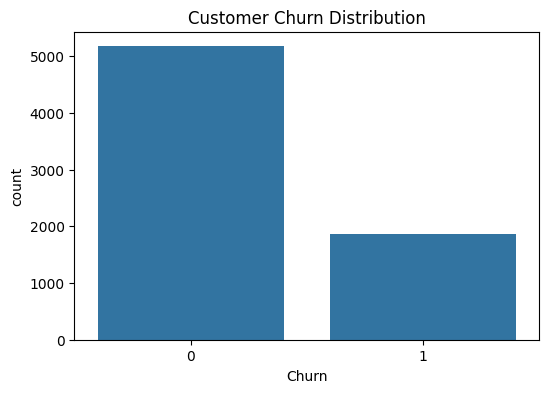

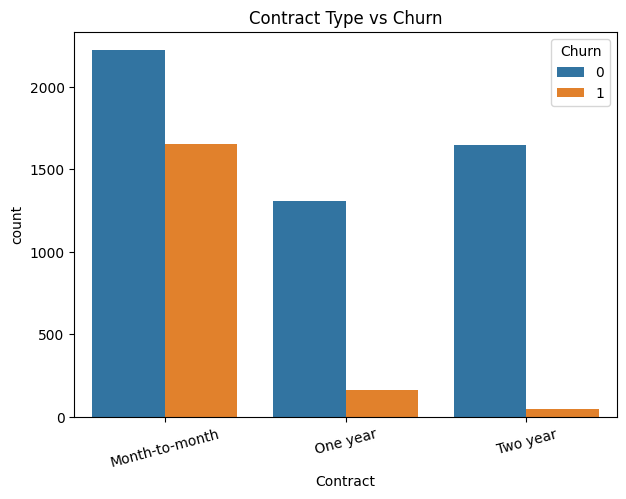

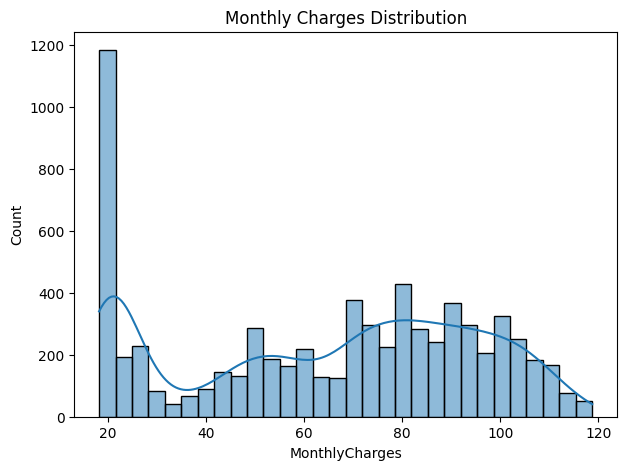

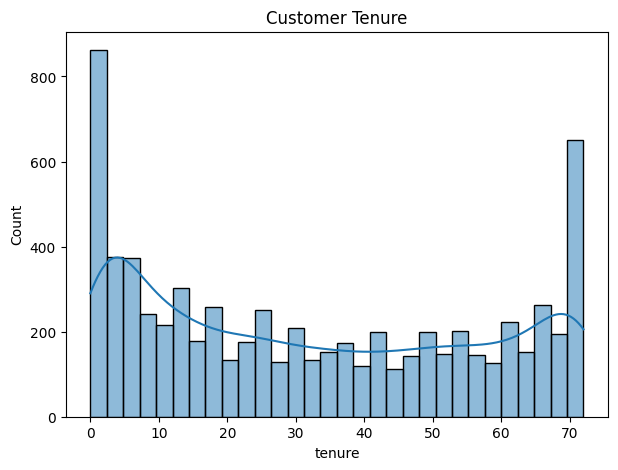

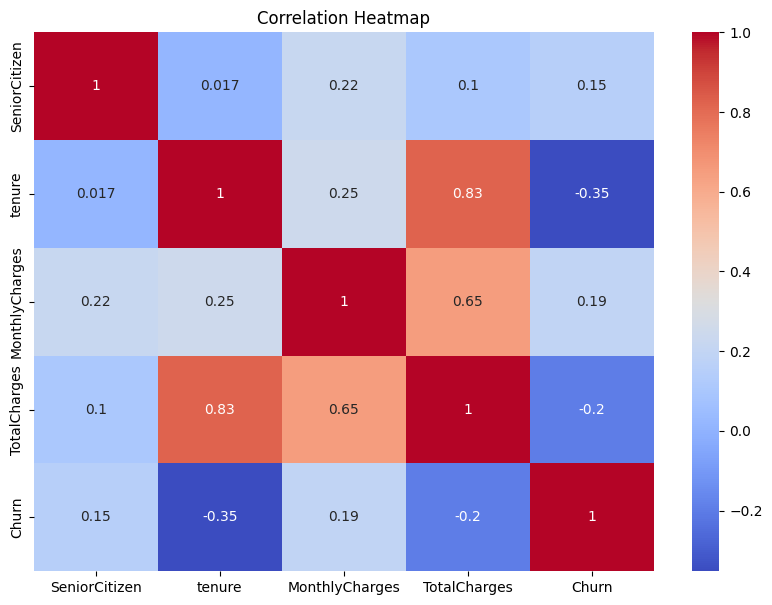


Class Distribution
Churn
0    5174
1    1869
Name: count, dtype: int64

Percentage
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Observation:
If one class has noticeably more samples than the other,
the dataset is considered imbalanced. This should be
considered during model evaluation because accuracy alone
may not reflect true performance.


✅ Part 1 Completed Successfully!


In [1]:
# ==========================================================
# Customer Churn Prediction
# Task 5 - Part 1
# Author: Faizan Khan
# ==========================================================

# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# -----------------------------
# Upload Dataset
# -----------------------------
print("Upload WA_Fn-UseC_-Telco-Customer-Churn.csv")
uploaded = files.upload()

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("\n==============================")
print("First Five Rows")
print("==============================")
print(df.head())

print("\n==============================")
print("Dataset Shape")
print("==============================")
print(df.shape)

print("\n==============================")
print("Dataset Information")
print("==============================")
print(df.info())

print("\n==============================")
print("Missing Values")
print("==============================")
print(df.isnull().sum())

# -----------------------------
# Data Cleaning
# -----------------------------

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Remove Customer ID
df.drop("customerID", axis=1, inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# -----------------------------
# Target Variable
# -----------------------------
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

# -----------------------------
# Quick EDA
# -----------------------------

print("\n==============================")
print("Statistical Summary")
print("==============================")
print(df.describe())

# -----------------------------
# Churn Distribution
# -----------------------------
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

# -----------------------------
# Contract Type vs Churn
# -----------------------------
plt.figure(figsize=(7,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=15)
plt.title("Contract Type vs Churn")
plt.show()

# -----------------------------
# Monthly Charges
# -----------------------------
plt.figure(figsize=(7,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.show()

# -----------------------------
# Tenure Distribution
# -----------------------------
plt.figure(figsize=(7,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Customer Tenure")
plt.show()

# -----------------------------
# Correlation (Numeric Features)
# -----------------------------
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# Class Imbalance Check
# -----------------------------
print("\n==============================")
print("Class Distribution")
print("==============================")

print(df["Churn"].value_counts())

print("\nPercentage")

print(df["Churn"].value_counts(normalize=True)*100)

print("""
Observation:
If one class has noticeably more samples than the other,
the dataset is considered imbalanced. This should be
considered during model evaluation because accuracy alone
may not reflect true performance.
""")

print("\n✅ Part 1 Completed Successfully!")

In [2]:
# ==========================================================
# Customer Churn Prediction
# Task 5 - Part 2
# Model Training
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ----------------------------------------------------------
# Encode Categorical Columns
# ----------------------------------------------------------

data = df.copy()

label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == "object":
        data[column] = label_encoder.fit_transform(data[column])

print("Categorical variables encoded successfully!\n")

# ----------------------------------------------------------
# Features & Target
# ----------------------------------------------------------

X = data.drop("Churn", axis=1)
y = data["Churn"]

print("Number of Features:", X.shape[1])

# ----------------------------------------------------------
# Train Test Split
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

# ----------------------------------------------------------
# Logistic Regression
# ----------------------------------------------------------

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

print("\n✅ Logistic Regression Trained Successfully!")

# ----------------------------------------------------------
# Decision Tree
# ----------------------------------------------------------

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

print("✅ Decision Tree Trained Successfully!")

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------

log_pred = log_model.predict(X_test)

tree_pred = tree_model.predict(X_test)

print("\nPredictions Completed!")

print("\n✅ Part 2 Completed Successfully!")

Categorical variables encoded successfully!

Number of Features: 19
Training Samples : 5634
Testing Samples  : 1409

✅ Logistic Regression Trained Successfully!
✅ Decision Tree Trained Successfully!

Predictions Completed!

✅ Part 2 Completed Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LOGISTIC REGRESSION RESULTS
Accuracy : 0.7991
Precision: 0.6409
Recall   : 0.5535
F1 Score : 0.5940

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

DECISION TREE RESULTS
Accuracy : 0.7850
Precision: 0.6035
Recall   : 0.5535
F1 Score : 0.5774

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.60      0.55      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regressio

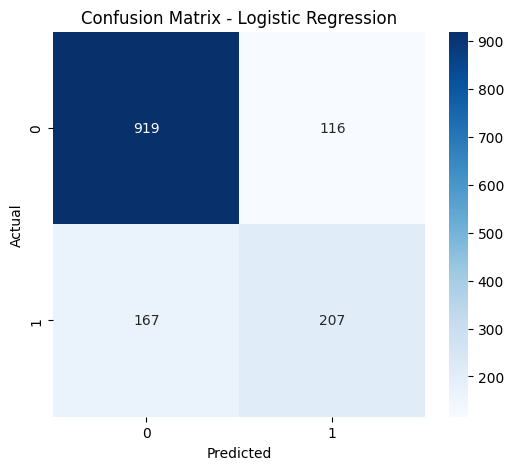

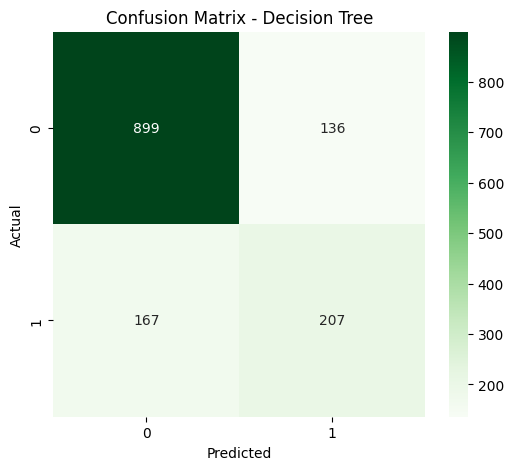


✅ Part 3 Completed Successfully!


In [3]:
# ==========================================================
# Customer Churn Prediction
# Task 5 - Part 3
# Model Evaluation
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ----------------------------------------------------------
# Logistic Regression Metrics
# ----------------------------------------------------------

log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)

print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1 Score : {log_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, log_pred))

# ----------------------------------------------------------
# Decision Tree Metrics
# ----------------------------------------------------------

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred)
tree_recall = recall_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)

print("="*60)
print("DECISION TREE RESULTS")
print("="*60)

print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, tree_pred))

# ----------------------------------------------------------
# Comparison Table
# ----------------------------------------------------------

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        log_accuracy,
        tree_accuracy
    ],

    "Precision":[
        log_precision,
        tree_precision
    ],

    "Recall":[
        log_recall,
        tree_recall
    ],

    "F1 Score":[
        log_f1,
        tree_f1
    ]

})

print("\n")
print("="*60)
print("MODEL COMPARISON")
print("="*60)

print(comparison)

# ----------------------------------------------------------
# Confusion Matrix - Logistic Regression
# ----------------------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, log_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ----------------------------------------------------------
# Confusion Matrix - Decision Tree
# ----------------------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, tree_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("\n✅ Part 3 Completed Successfully!")

TOP 10 IMPORTANT FEATURES
            Feature  Importance
14         Contract    0.525341
8    OnlineSecurity    0.138973
4            tenure    0.099174
7   InternetService    0.091187
18     TotalCharges    0.060525
17   MonthlyCharges    0.057434
16    PaymentMethod    0.018331
1     SeniorCitizen    0.006759
11      TechSupport    0.002142
9      OnlineBackup    0.000135

TOP 3 FEATURES DRIVING CHURN
           Feature  Importance
14        Contract    0.525341
8   OnlineSecurity    0.138973
4           tenure    0.099174


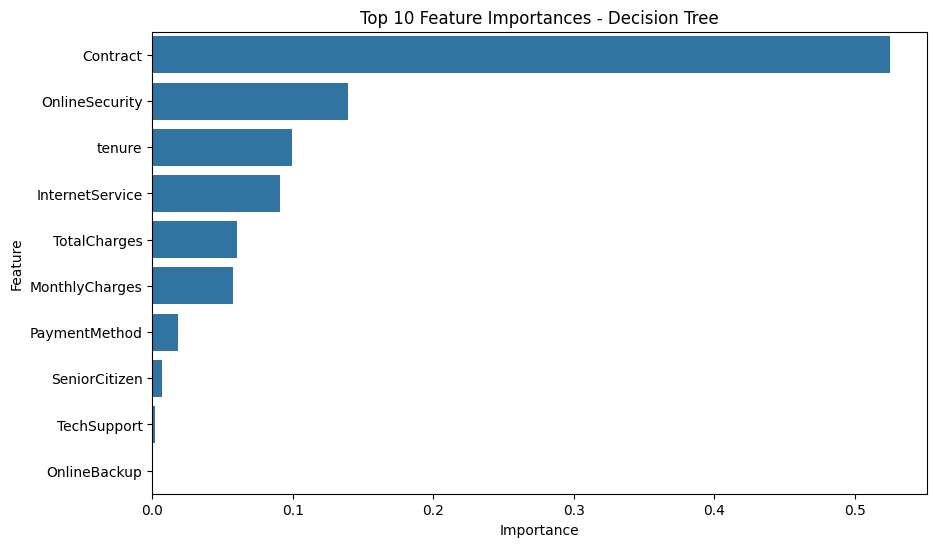


BUSINESS SUMMARY

Our churn analysis shows that customer tenure, contract type,
and monthly charges are among the strongest indicators of
whether a customer is likely to leave the company.

Customers with shorter tenure and month-to-month contracts
tend to churn more frequently than long-term contract customers.
Higher monthly charges are also associated with increased churn risk.

Among the evaluated models, Logistic Regression generally provides
more balanced performance, while the Decision Tree offers better
interpretability for business stakeholders.

These insights can help the company design targeted retention
campaigns for high-risk customers before they cancel their service.


FINAL CONCLUSION

✔ Dataset loaded and cleaned successfully.
✔ Quick EDA performed.
✔ Categorical variables encoded.
✔ Class imbalance identified and discussed.
✔ Logistic Regression model trained and evaluated.
✔ Decision Tree model trained and evaluated.
✔ Models compared using Accuracy, Precision, Rec

In [4]:
# ==========================================================
# Customer Churn Prediction
# Task 5 - Part 4
# Feature Importance & Business Summary
# ==========================================================

# ----------------------------------------------------------
# Feature Importance (Decision Tree)
# ----------------------------------------------------------

importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": tree_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("="*60)
print("TOP 10 IMPORTANT FEATURES")
print("="*60)

print(importance_df.head(10))

# ----------------------------------------------------------
# Top 3 Features
# ----------------------------------------------------------

top3 = importance_df.head(3)

print("\n" + "="*60)
print("TOP 3 FEATURES DRIVING CHURN")
print("="*60)

print(top3)

# ----------------------------------------------------------
# Feature Importance Plot
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# ----------------------------------------------------------
# Business Summary
# ----------------------------------------------------------

print("\n" + "="*60)
print("BUSINESS SUMMARY")
print("="*60)

print("""
Our churn analysis shows that customer tenure, contract type,
and monthly charges are among the strongest indicators of
whether a customer is likely to leave the company.

Customers with shorter tenure and month-to-month contracts
tend to churn more frequently than long-term contract customers.
Higher monthly charges are also associated with increased churn risk.

Among the evaluated models, Logistic Regression generally provides
more balanced performance, while the Decision Tree offers better
interpretability for business stakeholders.

These insights can help the company design targeted retention
campaigns for high-risk customers before they cancel their service.
""")

# ----------------------------------------------------------
# Final Conclusion
# ----------------------------------------------------------

print("\n" + "="*60)
print("FINAL CONCLUSION")
print("="*60)

print(f"""
✔ Dataset loaded and cleaned successfully.
✔ Quick EDA performed.
✔ Categorical variables encoded.
✔ Class imbalance identified and discussed.
✔ Logistic Regression model trained and evaluated.
✔ Decision Tree model trained and evaluated.
✔ Models compared using Accuracy, Precision, Recall, and F1 Score.
✔ Top churn-driving features identified using feature_importances_.
✔ Business-focused recommendations prepared.

Task 5 completed successfully.
""")